In [1]:
import torch
import torchvision
import torchvision.transforms as T
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.metrics import confusion_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# DATA

In [4]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])

In [5]:
trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = trainset.classes

100%|██████████| 170M/170M [00:03<00:00, 48.8MB/s]


# MODEL

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x, enable_dropout=False):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = self.dropout(x) if enable_dropout else x
        x = F.relu(self.fc1(x))
        x = self.dropout(x) if enable_dropout else x

        return self.fc2(x)

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def train(model, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x, y in trainloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch}: loss={total_loss:.3f}")

train(model)

Epoch 0: loss=1090.281
Epoch 1: loss=761.710
Epoch 2: loss=616.361
Epoch 3: loss=522.390
Epoch 4: loss=440.493


#Metrics for a model

In [8]:
def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [9]:
def per_class_accuracy(model, dataloader, num_classes=10, device="cpu"):
    model.eval()

    correct = [0]*num_classes
    total = [0]*num_classes

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)

            for i in range(len(y)):
                label = y[i].item()
                total[label] += 1
                correct[label] += (preds[i] == label).item()

    return [c/t for c, t in zip(correct, total)]

In [10]:

def get_confusion_matrix(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    return confusion_matrix(all_labels, all_preds)

Accuracy: 0.7479
Per class accuracy: [0.881, 0.851, 0.603, 0.621, 0.707, 0.67, 0.776, 0.724, 0.837, 0.809]


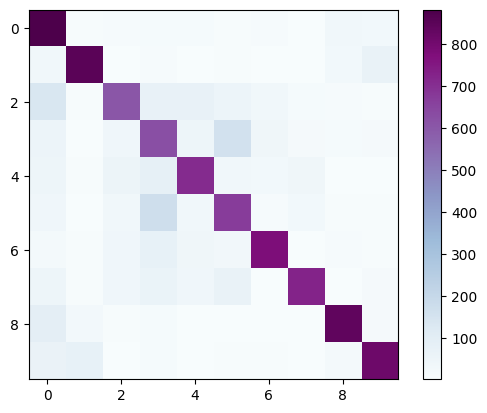

In [11]:

print("Accuracy:", evaluate_accuracy(model, testloader, device))
print("Per class accuracy:", per_class_accuracy(model, testloader, device=device))

plt.imshow(get_confusion_matrix(model, testloader, device), cmap='BuPu')
plt.colorbar()
plt.show()


# Save

In [12]:
def save_model(model, path="checkpoints/model.pth"):
    os.makedirs(os.path.dirname(path), exist_ok=True)

    torch.save({
        "model_state_dict": model.state_dict(),
    }, path)

    print(f"Model saved to {path}")

In [13]:
def load_model(model, path="checkpoints/model.pth", device="cpu"):
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)

    model.eval()

    print(f"Model loaded from {path}")
    return model

In [14]:
save_model(model)

Model saved to checkpoints/model.pth


In [15]:
model = load_model(SimpleCNN().to(device), device=device)

Model loaded from checkpoints/model.pth


# Interpretation

In [16]:
def enable_dropout(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

In [17]:
def mc_dropout_predict(model, x, T=20):
    model.eval()
    enable_dropout(model)

    preds = []

    for _ in range(T):
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        preds.append(probs.unsqueeze(0))

    preds = torch.cat(preds, dim=0)

    mean = preds.mean(dim=0)
    var = preds.var(dim=0)

    entropy = -(mean * torch.log(mean + 1e-8)).sum(dim=1)

    return preds, mean, var, entropy

In [18]:
def compute_mc_metrics(samples, labels):

    mean_probs = samples.mean(dim=0)

    preds = mean_probs.argmax(dim=1)

    confidence = mean_probs.max(dim=1).values
    entropy = -(mean_probs * torch.log(mean_probs + 1e-8)).sum(dim=1)

    correct = (preds == labels).float()

    epistemic_var = samples.var(dim=0).mean(dim=1)

    return confidence, entropy, correct, preds, epistemic_var

In [19]:
def integrated_gradients(model, x, target_class, baseline=None, steps=50):
    model.eval()

    if baseline is None:
        baseline = torch.zeros_like(x)

    x = x.clone().detach()
    baseline = baseline.clone().detach()

    alphas = torch.linspace(0, 1, steps).to(x.device)

    total_gradients = torch.zeros_like(x)

    for alpha in alphas:
        interpolated = baseline + alpha * (x - baseline)
        interpolated.requires_grad_(True)

        output = model(interpolated)
        score = output[:, target_class]

        model.zero_grad()
        score.backward()

        total_gradients += interpolated.grad

    avg_gradients = total_gradients / steps

    ig = (x - baseline) * avg_gradients

    return ig.detach()

In [20]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activations)
        self.target_layer.register_full_backward_hook(self.save_gradients)

    def save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def save_activations(self, module, inp, out):
        self.activations = out.detach()

    def __call__(self, x, target_class):
        self.model.eval()

        self.gradients = None
        self.activations = None

        x = x.to(next(self.model.parameters()).device)

        logits = self.model(x)

        self.model.zero_grad()

        score = logits[0, target_class]
        score.backward()

        pooled_grads = self.gradients.mean(dim=[0, 2, 3])

        cam = torch.zeros(
            self.activations.shape[2:],
            device=self.activations.device
        )

        for i in range(self.activations.shape[1]):
            cam += pooled_grads[i] * self.activations[0, i]

        cam = torch.relu(cam)
        cam = cam / (cam.max() + 1e-8)

        return cam.detach().cpu()

In [21]:
class IGWrapper:
    def __init__(self, model):
        self.model = model

    def __call__(self, x, target_class):
        return integrated_gradients(self.model, x, target_class)


In [22]:
def normalize(x):
    x = x - x.min()
    return x / (x.max() + 1e-8)

In [23]:
def resize_cam(cam, target_shape):
    cam = cam.unsqueeze(0).unsqueeze(0)
    cam = F.interpolate(cam, size=target_shape, mode="bilinear", align_corners=False)
    return cam.squeeze()

In [24]:
def cosine_similarity(a, b):
    a, b = a.flatten(), b.flatten()
    return F.cosine_similarity(a, b, dim=0).item()


def sparsity(x):
    return (x < 0.1).float().mean().item()

In [25]:
def correlation(a, b):
    a = a.flatten()
    b = b.flatten()
    a = (a - a.mean()) / (a.std() + 1e-8)
    b = (b - b.mean()) / (b.std() + 1e-8)
    return (a * b).mean().item()

In [26]:
def topk_overlap(a, b, k=50):
    a_flat = a.flatten()
    b_flat = b.flatten()

    a_top = torch.topk(a_flat, k).indices
    b_top = torch.topk(b_flat, k).indices

    return len(set(a_top.tolist()) & set(b_top.tolist())) / k

# Logging

In [27]:
class Logger:
    def __init__(self):
        self.rows = []

    def log(self, **kwargs):
        self.rows.append(kwargs)

    def to_df(self):
        return pd.DataFrame(self.rows)

    def save(self, path="results.csv"):
        self.to_df().to_csv(path, index=False)

In [28]:
def compute_metrics(probs, labels, preds):
    confidence = probs.max(dim=1).values
    entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=1)

    correct = (preds == labels).float()

    return confidence, entropy, correct

In [29]:
def stability_score(map1, map2):
    return cosine_similarity(map1, map2)

In [30]:
def evaluate(model, dataloader, ig_fn, gradcam_fn, device, logger, n_batches=10):
    model.eval()

    for i, (x, y) in enumerate(dataloader):

        if i >= n_batches:
            break

        x, y = x.to(device), y.to(device)

        samples = []

        for _ in range(10):
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            samples.append(probs.unsqueeze(0))

        samples = torch.cat(samples, dim=0)

        confidence, entropy, correct, preds, epistemic_var = compute_mc_metrics(samples, y)

        for j in range(x.size(0)):

            # --- interpretability ---
            ig = ig_fn(x[j:j+1], preds[j].item())
            cam = gradcam_fn(x[j:j+1], preds[j].item())

            ig_map = ig.mean(dim=1).squeeze().detach().cpu()
            ig_map = torch.relu(ig_map)

            cam_map = resize_cam(cam, ig_map.shape).detach().cpu()
            sim = cosine_similarity(ig_map, cam_map)
            corr = correlation(ig_map, cam_map)
            topk = topk_overlap(ig_map, cam_map)

            logger.log(
                label=y[j].item(),
                pred=preds[j].item(),
                correct=correct[j].item(),
                confidence=confidence[j].item(),
                entropy=entropy[j].item(),
                ig_cam_similarity=sim,
                corr = corr,
                topk = topk
            )

# PLOTS

In [31]:
def plot_confidence_accuracy(df, ax=None):

    if ax is None:
        fig, ax = plt.subplots()

    bins = pd.cut(df["confidence"], 10)
    grouped = df.groupby(bins)["correct"].mean()

    grouped.plot(kind="bar", ax=ax)
    ax.set_title("Confidence vs Accuracy")

In [32]:
def plot_entropy(df, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    ax.scatter(df["entropy"], df["correct"], alpha=0.3)
    ax.set_title("Entropy vs Correctness")
    ax.set_xlabel("Entropy")
    ax.set_ylabel("Correct")

In [33]:
def plot_similarity(df, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    ax.hist(df["ig_cam_similarity"], bins=30)
    ax.set_title("IG vs CAM Similarity")

In [34]:
def plot_conf_vs_sim(df, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    ax.scatter(df["confidence"], df["ig_cam_similarity"], alpha=0.3)
    ax.set_title("Confidence vs Similarity")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Similarity")

In [35]:
def plot_corr(df, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    ax.hist(df["corr"], bins=20)
    ax.set_title("Correlation distribution (IG vs CAM)")
    ax.set_xlabel("Correlation")
    ax.set_ylabel("Count")

In [36]:
def plot_conf_vs_topk(df, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    ax.scatter(df["confidence"], df["topk"], alpha=0.3)

    ax.set_title("Confidence vs Top-K Overlap")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Top-K overlap")

In [37]:
def plot_conf_vs_corr(df, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    ax.scatter(df["confidence"], df["corr"], alpha=0.3)

    ax.set_title("Confidence vs Correlation (IG vs CAM)")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Correlation")

In [38]:
def plot_topk(df, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    ax.hist(df["topk"], bins=20)
    ax.set_title("Top-K overlap distribution")
    ax.set_xlabel("Top-K overlap")
    ax.set_ylabel("Count")

In [39]:
def plot_all(df):
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))

    plot_confidence_accuracy(df, axes[0, 0])
    plot_entropy(df, axes[0, 1])
    plot_similarity(df, axes[0, 2])
    plot_conf_vs_sim(df, axes[0, 3])

    plot_conf_vs_corr(df, axes[1, 0])
    plot_conf_vs_topk(df, axes[1, 1])
    plot_topk(df, axes[1, 2])
    plot_corr(df, axes[1, 3])

    plt.tight_layout()
    plt.show()

In [40]:
logger = Logger()
ig_fn = IGWrapper(model)
gradcam_fn = GradCAM(model, model.conv3)

evaluate(
    model=model,
    dataloader=testloader,
    ig_fn=ig_fn,
    gradcam_fn=gradcam_fn,
    device=device,
    logger=logger,
    n_batches=20
)


/tmp/ipykernel_3708/1924126632.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(bins)["correct"].mean()


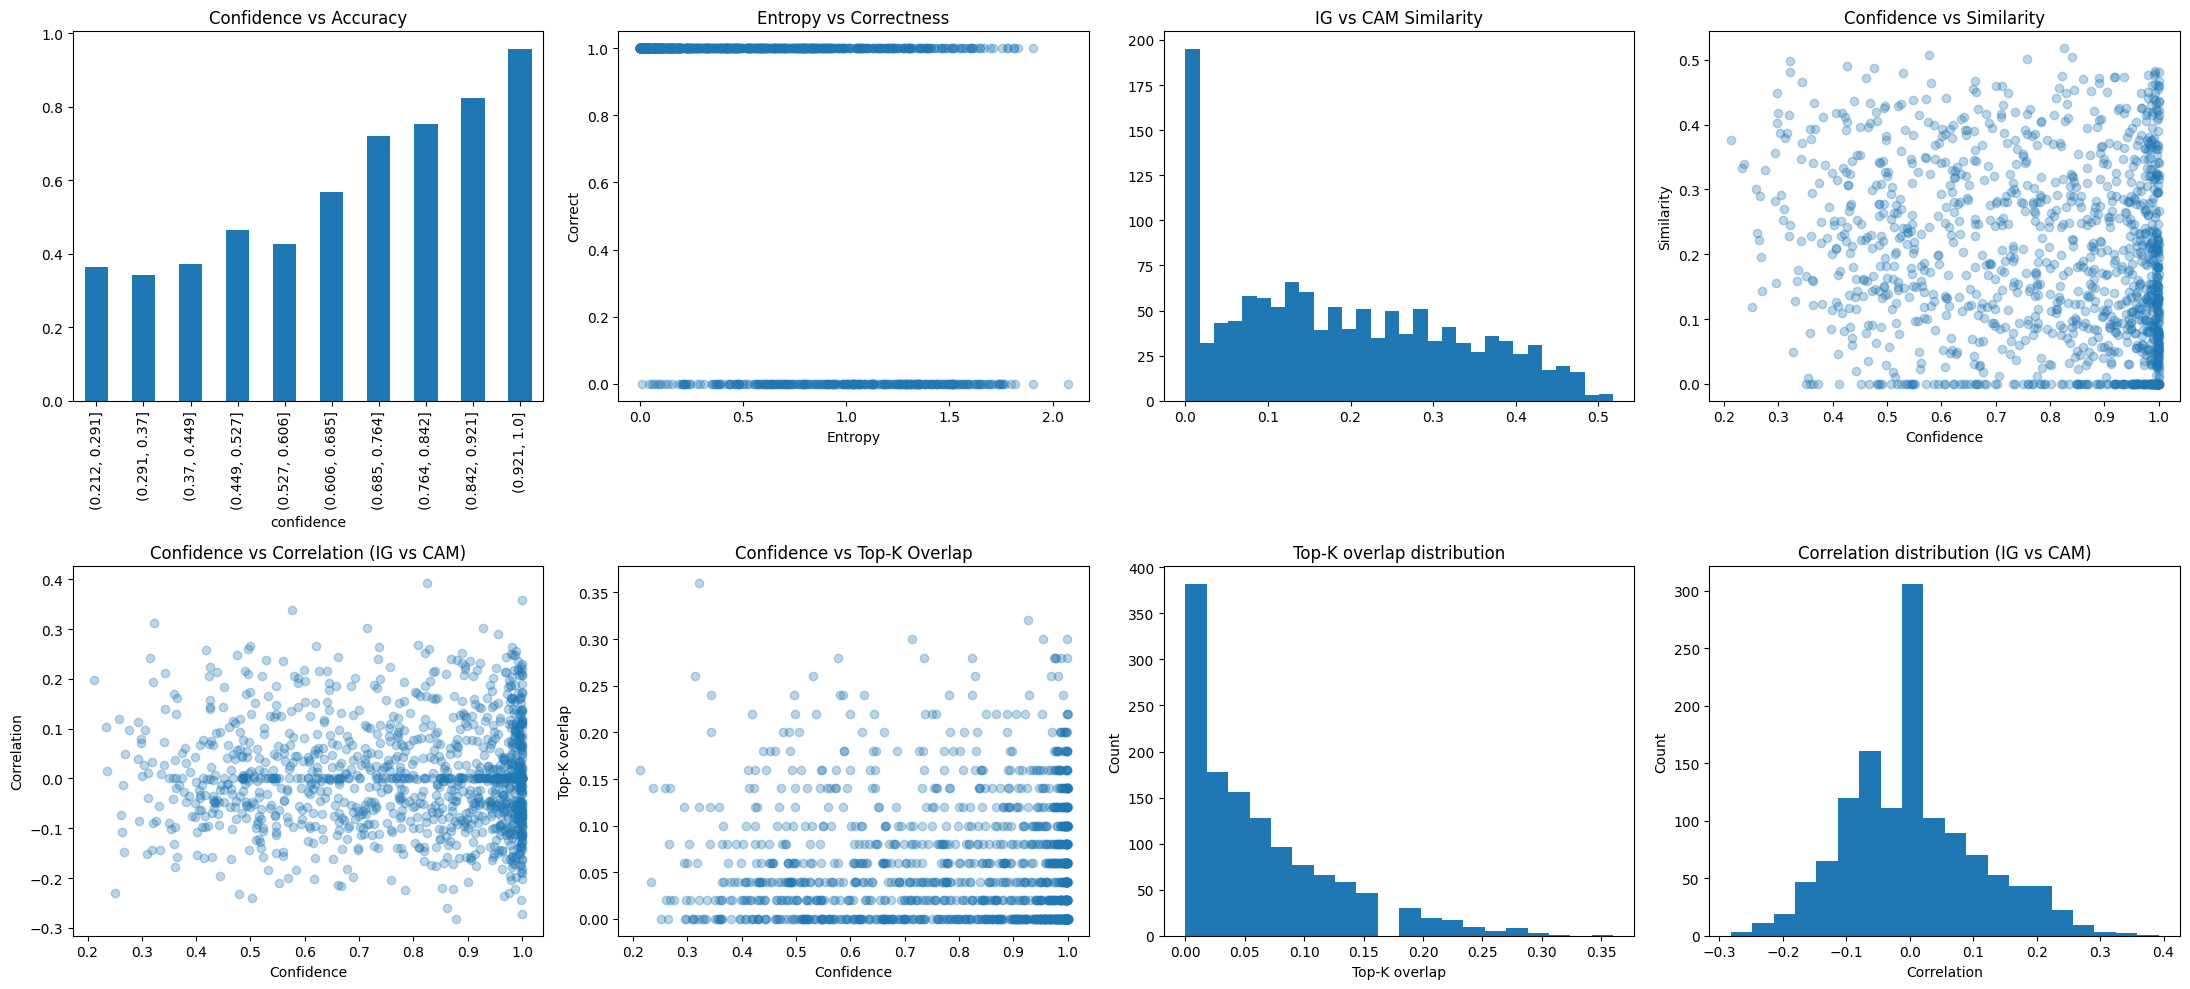

In [41]:
df = logger.to_df()
df.to_csv("results.csv", index=False)

plot_all(df)

#Example

In [42]:
def run_example(i=0):
    x, y = testset[i]
    x_batch = x.unsqueeze(0).to(device)

    preds, mean, var, ent = mc_dropout_predict(model, x_batch)

    pred_class = mean.argmax(dim=1).item()

    ig_attr = ig_fn(x_batch, pred_class)
    cam = gradcam_fn(x_batch, pred_class)

    ig_map = ig_attr[0].mean(dim=0).detach().cpu()
    cam_map = cam.detach().cpu()
    cam_map_resized = resize_cam(cam_map, ig_map.shape)

    sim_cos = torch.nn.functional.cosine_similarity(
        ig_map.flatten(),
        cam_map_resized.flatten(),
        dim=0
    ).item()

    sim_topk = topk_overlap(ig_map, cam_map_resized, k=50)

    sim_corr = correlation(ig_map, cam_map_resized)



    print("GT:", classes[y])
    print("Pred:", classes[pred_class])
    print("Uncertainty entropy:", ent.item())

    print("\nInterpretability agreement:")
    print("Cosine similarity:", sim_cos)
    print("Top-k overlap:", sim_topk)
    print("Correlation:", sim_corr)




    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(x.permute(1, 2, 0))
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Grad-CAM")
    plt.imshow(cam_map_resized, cmap="jet")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Integrated Gradients")
    plt.imshow(ig_map, cmap="jet")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

GT: cat
Pred: cat
Uncertainty entropy: 0.8312475681304932

Interpretability agreement:
Cosine similarity: 0.03690820187330246
Top-k overlap: 0.12
Correlation: 0.020588025450706482


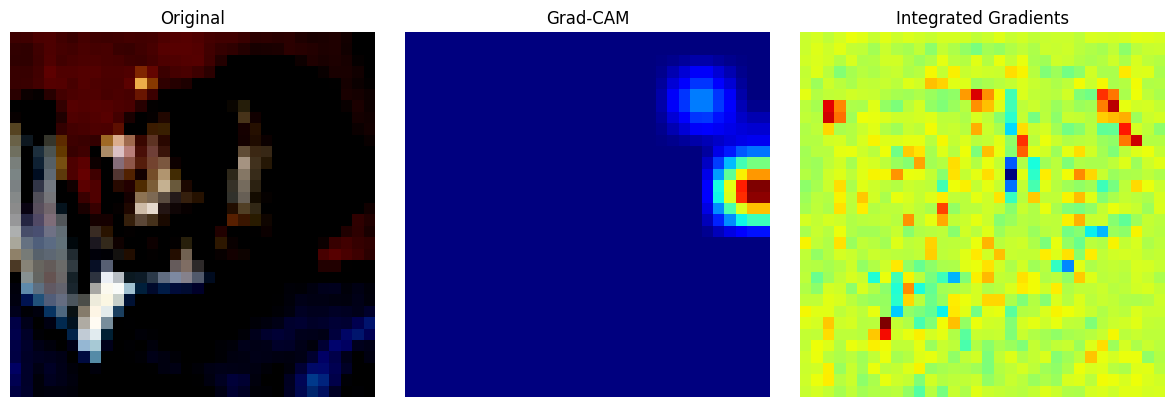

GT: ship
Pred: ship
Uncertainty entropy: 0.0325811505317688

Interpretability agreement:
Cosine similarity: 0.0
Top-k overlap: 0.12
Correlation: 0.0


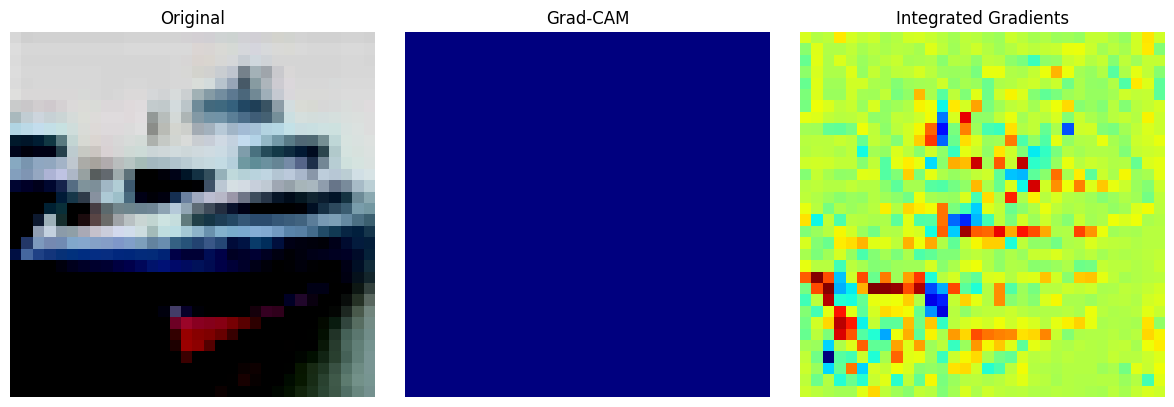

GT: ship
Pred: airplane
Uncertainty entropy: 0.9401791095733643

Interpretability agreement:
Cosine similarity: -0.005327362567186356
Top-k overlap: 0.02
Correlation: -0.02072557620704174


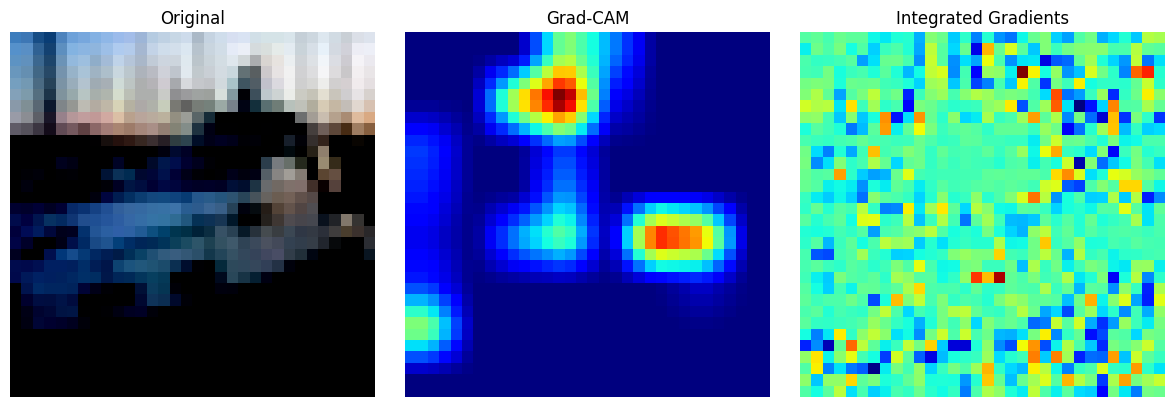

GT: airplane
Pred: airplane
Uncertainty entropy: 0.29744043946266174

Interpretability agreement:
Cosine similarity: 0.0006107166409492493
Top-k overlap: 0.02
Correlation: -0.012242550030350685


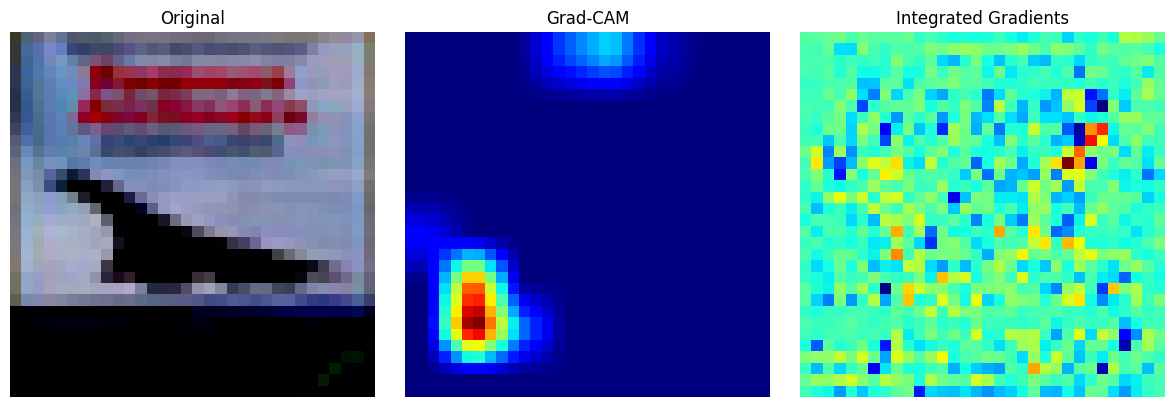

GT: frog
Pred: frog
Uncertainty entropy: 0.7091625928878784

Interpretability agreement:
Cosine similarity: 0.16812743246555328
Top-k overlap: 0.22
Correlation: 0.1415320187807083


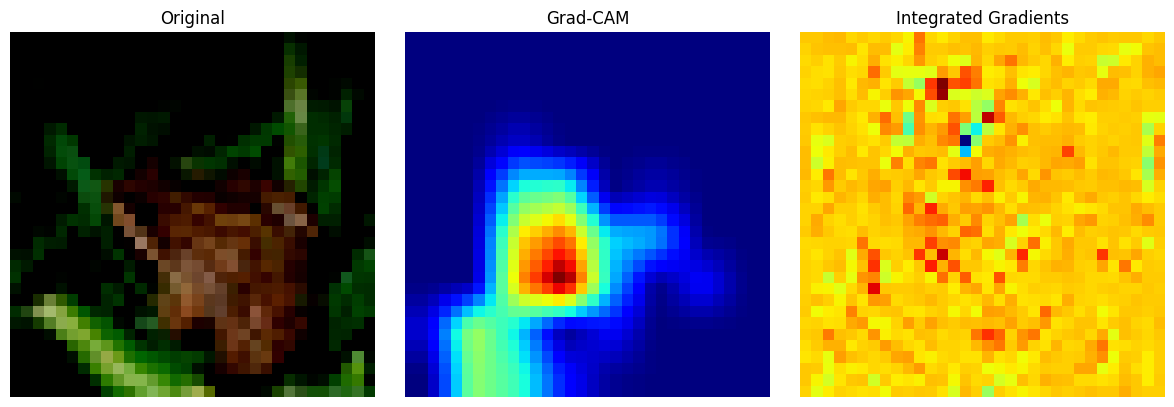

GT: frog
Pred: dog
Uncertainty entropy: 0.9809595346450806

Interpretability agreement:
Cosine similarity: 0.0688415989279747
Top-k overlap: 0.0
Correlation: 0.042224109172821045


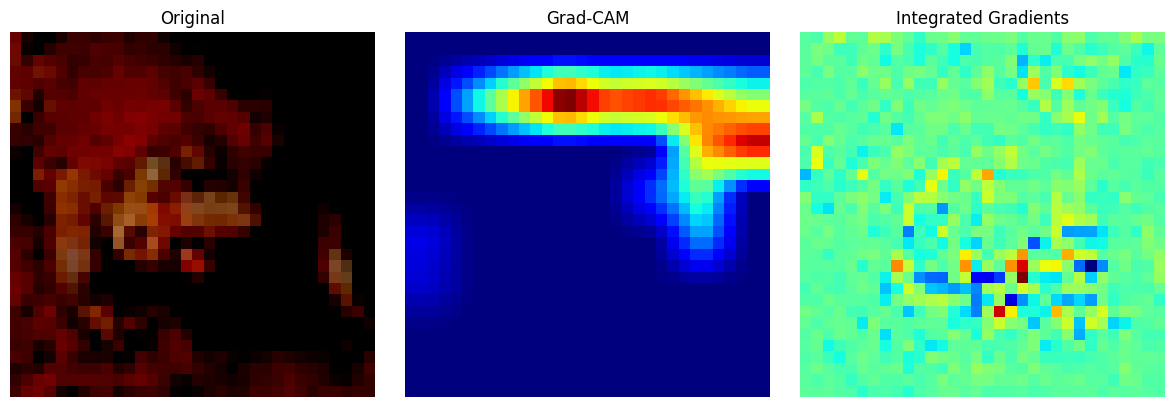

GT: automobile
Pred: automobile
Uncertainty entropy: 0.48693788051605225

Interpretability agreement:
Cosine similarity: 0.020149648189544678
Top-k overlap: 0.12
Correlation: -0.03498489409685135


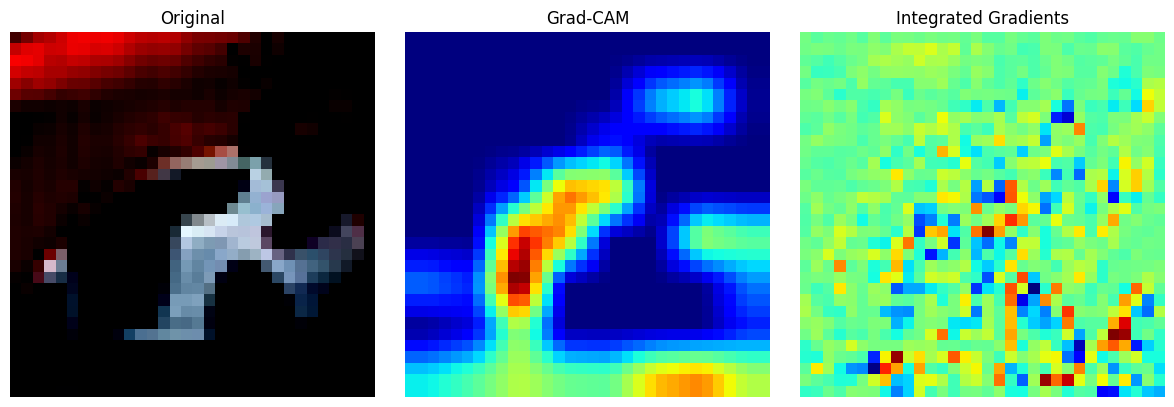

GT: frog
Pred: deer
Uncertainty entropy: 1.0291622877120972

Interpretability agreement:
Cosine similarity: 0.02506137453019619
Top-k overlap: 0.0
Correlation: -0.0028970614075660706


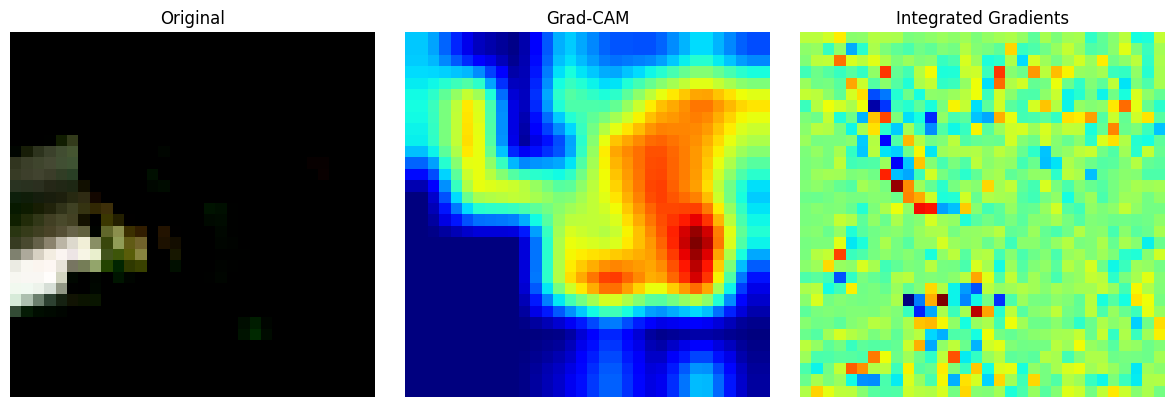

GT: cat
Pred: cat
Uncertainty entropy: 0.11572937667369843

Interpretability agreement:
Cosine similarity: 0.0
Top-k overlap: 0.08
Correlation: 0.0


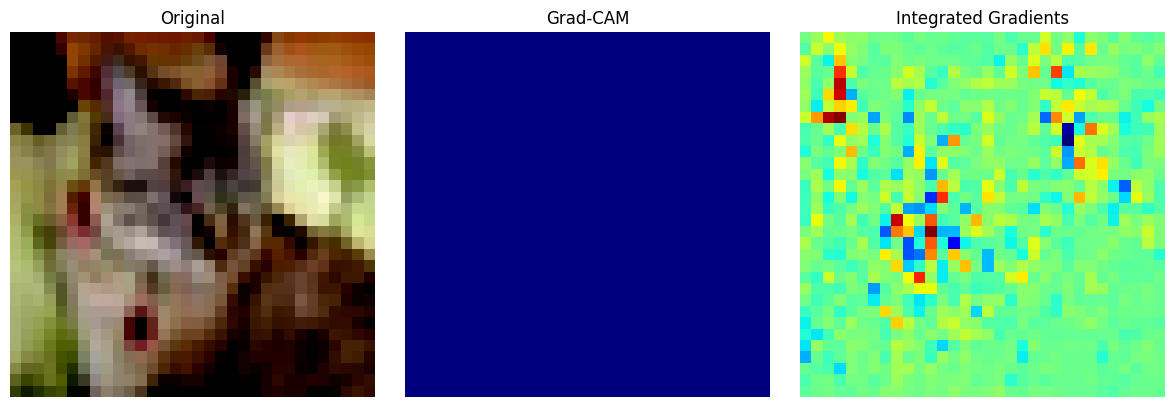

GT: automobile
Pred: automobile
Uncertainty entropy: 0.4208756685256958

Interpretability agreement:
Cosine similarity: 0.0
Top-k overlap: 0.04
Correlation: 0.0


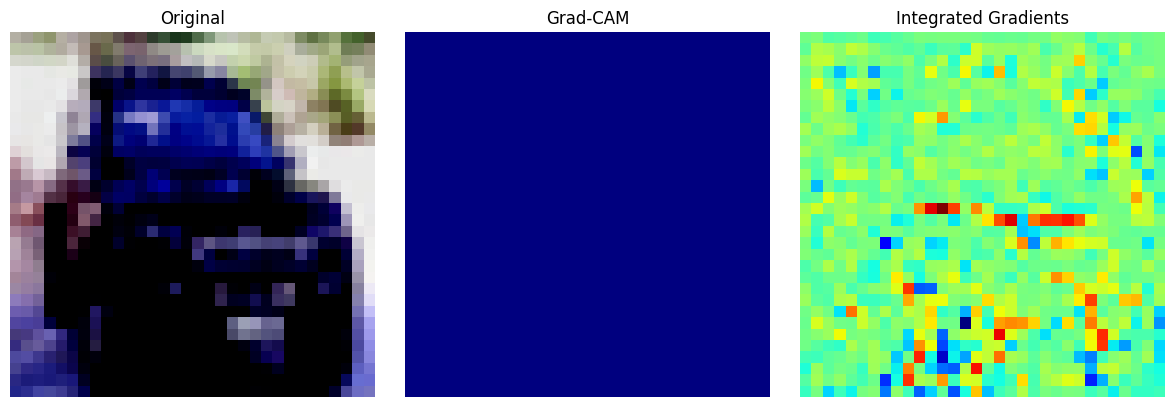

In [44]:
for i in range(10):
    run_example(i)
    plt.show()